# Distributional Stability and Feature Drift

## Research Objective

The previous stage evaluated feature stability using summary statistics:

- Mean stability
- Standard-deviation stability
- Coefficient-of-variation stability

However, summary statistics do not fully describe a distribution.

Two windows can have similar means and standard deviations while their underlying distributions differ substantially.

Therefore, the next stage evaluates **distributional stability**.

The purpose is to answer:

> Does the distribution of a feature remain consistent across data windows?

If the distribution changes significantly, the feature is considered to exhibit **distributional drift**.

---

## 1. Why Distributional Stability Is Required

Mean and standard deviation provide only partial information about a feature.

For example:

- Window A and Window B may have similar means.
- Their standard deviations may also be similar.
- However, their distributions may differ in skewness, tails, concentration, or multimodality.

Therefore:

$$
\text{Statistical Stability} \neq \text{Distributional Stability}
$$

Distributional analysis provides an additional layer of evidence for feature reliability.

---

## 2. Distributional Comparison Strategy

For each feature, consecutive windows are compared:

$$
W_1 \rightarrow W_2
$$

$$
W_2 \rightarrow W_3
$$

$$
W_3 \rightarrow W_4
$$

$$
W_4 \rightarrow W_5
$$

For each pair of windows, multiple distributional measures are calculated.

---

## 3. Kolmogorov-Smirnov (KS) Statistic

The two-sample KS statistic measures the maximum difference between the empirical cumulative distribution functions of two samples.

$$
KS = \sup_x |F_1(x)-F_2(x)|
$$

where:

- $F_1(x)$ = empirical CDF of the first window
- $F_2(x)$ = empirical CDF of the second window

Interpretation:

- Lower KS → more similar distributions
- Higher KS → greater distributional shift

The KS statistic is used as a **distributional difference score**, not merely as a hypothesis-test p-value.

---

## 4. Wasserstein Distance

Wasserstein distance measures the minimum amount of "work" required to transform one probability distribution into another.

For one-dimensional distributions:

$$
W(P,Q)
$$

A larger value indicates a greater shift between the distributions.

Unlike the KS statistic, Wasserstein distance retains information about the magnitude and location of the distributional movement.

Because features have different scales, normalized Wasserstein distance will also be considered where appropriate.

---

## 5. Population Stability Index (PSI)

PSI compares the proportion of observations falling into corresponding bins between two populations.

$$
PSI =
\sum_i
(A_i-E_i)
\ln\left(\frac{A_i}{E_i}\right)
$$

where:

- $A_i$ = proportion in the current/reference comparison population
- $E_i$ = proportion in the reference population

A larger PSI indicates greater population shift.

PSI is particularly useful for practical monitoring because it summarizes distributional change into a single interpretable value.

---

## 6. Multi-Statistic Distributional Assessment

The distributional stability layer therefore contains:

| Metric | What it captures |
|---|---|
| **KS Statistic** | Maximum difference between empirical distributions |
| **Wasserstein Distance** | Magnitude of distribution movement |
| **PSI** | Population-level distribution shift |

Using multiple measures reduces dependence on a single drift statistic.

---

## 7. Pairwise Window Analysis

Distributional drift is calculated between consecutive windows rather than comparing every window independently.

For five windows:

| Comparison | Interpretation |
|---|---|
| W1 → W2 | Initial distributional change |
| W2 → W3 | Subsequent change |
| W3 → W4 | Subsequent change |
| W4 → W5 | Most recent change |

This allows the framework to identify not only whether drift exists, but also **when the distribution begins to change**.

---

## 8. Important Difference from CV

CV is not suitable for features whose mean is close to zero.

However, distributional metrics do not depend on the feature mean being sufficiently far from zero.

Therefore:

> Near-zero-mean features excluded from CV analysis remain eligible for distributional drift analysis.

This is particularly important for anonymized variables in the Credit Card Fraud dataset.

---

## 9. Distributional Drift Score

At this stage, the individual drift metrics are retained separately.

We will **not immediately combine them into the final Feature Reliability Score**.

The output will contain:

- Mean KS
- Maximum KS
- Mean Wasserstein distance
- Maximum Wasserstein distance
- Mean PSI
- Maximum PSI

These metrics will later contribute to the overall feature reliability framework.

---

## 10. Research Question at This Stage

The current stage investigates:

> **"Does a feature maintain a similar probability distribution across data windows?"**

The next research question will be:

> **"Does distributional instability correspond to changes in feature importance and ML performance?"**

This distinction is important because statistical drift alone does not prove that a feature is harmful to a model.

---

## Current Research Progress

Raw Data
↓
Data Quality Assessment
↓
Window Construction
↓
Multi-Statistic Stability
├── Mean Stability
├── Standard-Deviation Stability
├── CV Stability
└── Near-Zero Mean Handling
↓
**Distributional Stability / Feature Drift ← CURRENT STAGE**
├── KS Statistic
├── Wasserstein Distance
└── PSI
↓
Feature Importance Stability
↓
Feature Reliability Score (FRS)
↓
ML Performance Evaluation
↓
Performance Degradation Analysis
↓
Final Data-Centric Feature Reliability Framework

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
loan_df = pd.read_csv("..\datasets\loan_data_set.csv")

print("Dataset shape:", loan_df.shape)
loan_df.head()

Dataset shape: (614, 13)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
# ============================================================
#  DISTRIBUTIONAL STABILITY / FEATURE DRIFT
# ============================================================

import numpy as np
import pandas as pd

from scipy.stats import ks_2samp
from scipy.stats import wasserstein_distance


# ------------------------------------------------------------
# 1. PSI FUNCTION
# ------------------------------------------------------------

def calculate_psi(reference, current, bins=10, epsilon=1e-6):
    """
    Calculate Population Stability Index (PSI)
    between a reference distribution and a current distribution.
    """

    reference = pd.Series(reference).dropna().astype(float)
    current = pd.Series(current).dropna().astype(float)

    if len(reference) == 0 or len(current) == 0:
        return np.nan

    # Use reference quantiles to create bins
    quantiles = np.linspace(0, 1, bins + 1)

    breakpoints = np.unique(
        np.quantile(reference, quantiles)
    )

    # If there are not enough unique values,
    # fall back to equally spaced bins
    if len(breakpoints) < 3:

        min_val = min(reference.min(), current.min())
        max_val = max(reference.max(), current.max())

        if min_val == max_val:
            return 0.0

        breakpoints = np.linspace(
            min_val,
            max_val,
            bins + 1
        )

    # Extend boundaries
    breakpoints[0] = -np.inf
    breakpoints[-1] = np.inf

    reference_bins = pd.cut(
        reference,
        bins=breakpoints,
        include_lowest=True
    )

    current_bins = pd.cut(
        current,
        bins=breakpoints,
        include_lowest=True
    )

    reference_pct = (
        reference_bins
        .value_counts(normalize=True, sort=False)
        .values
    )

    current_pct = (
        current_bins
        .value_counts(normalize=True, sort=False)
        .values
    )

    # Prevent division by zero
    reference_pct = np.clip(
        reference_pct,
        epsilon,
        None
    )

    current_pct = np.clip(
        current_pct,
        epsilon,
        None
    )

    psi = np.sum(
        (current_pct - reference_pct)
        * np.log(current_pct / reference_pct)
    )

    return psi


# ------------------------------------------------------------
# 2. DISTRIBUTIONAL COMPARISON FUNCTION
# ------------------------------------------------------------

def compare_distributions(reference, current, bins=10):

    reference = pd.Series(reference).dropna().astype(float)
    current = pd.Series(current).dropna().astype(float)

    if len(reference) == 0 or len(current) == 0:
        return {
            "KS_Statistic": np.nan,
            "KS_pvalue": np.nan,
            "Wasserstein": np.nan,
            "PSI": np.nan
        }

    # KS test
    ks_stat, ks_pvalue = ks_2samp(
        reference,
        current
    )

    # Wasserstein distance
    wasserstein = wasserstein_distance(
        reference,
        current
    )

    # PSI
    psi = calculate_psi(
        reference,
        current,
        bins=bins
    )

    return {
        "KS_Statistic": ks_stat,
        "KS_pvalue": ks_pvalue,
        "Wasserstein": wasserstein,
        "PSI": psi
    }

In [2]:
# ============================================================
# 3. PAIRWISE DISTRIBUTIONAL DRIFT
# ============================================================

def calculate_distributional_drift(windows, features, bins=10):

    results = []

    for feature in features:

        for i in range(len(windows) - 1):

            reference = windows[i][feature]
            current = windows[i + 1][feature]

            metrics = compare_distributions(
                reference,
                current,
                bins=bins
            )

            results.append({
                "Feature": feature,
                "Window_From": i + 1,
                "Window_To": i + 2,
                **metrics
            })

    return pd.DataFrame(results)

In [7]:
# ------------------------------------------------------------
# 4. CREATE SEQUENTIAL WINDOWS + SELECT NUMERICAL FEATURES
# ------------------------------------------------------------

# Create 5 sequential windows while preserving DataFrame structure
window_indices = np.array_split(np.arange(len(loan_df)), 5)

windows = [
    loan_df.iloc[idx].copy()
    for idx in window_indices
]

# Check window sizes
print("Number of windows:", len(windows))
print("Window sizes:", [len(window) for window in windows])

# Select numerical features
features = windows[0].select_dtypes(
    include=np.number
).columns.tolist()

print("\nNumerical features:")
print(features)

Number of windows: 5
Window sizes: [123, 123, 123, 123, 122]

Numerical features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']


In [8]:
# ------------------------------------------------------------
# 5. CALCULATE DISTRIBUTIONAL DRIFT
# ------------------------------------------------------------

distribution_drift = calculate_distributional_drift(
    windows=windows,
    features=features,
    bins=10
)

distribution_drift.head()

,Feature,Window_From,Window_To,KS_Statistic,KS_pvalue,Wasserstein,PSI
0,ApplicantIncome,1,2,0.138211,0.191061,1848.577236,0.118162
1,ApplicantIncome,2,3,0.138211,0.191061,1177.495935,0.196956
2,ApplicantIncome,3,4,0.097561,0.603827,818.902439,0.101536
3,ApplicantIncome,4,5,0.096428,0.560808,1115.076236,0.141261
4,CoapplicantIncome,1,2,0.138211,0.191061,376.894309,0.082659


## Aggregate Drift Across Windows

In [9]:
# ============================================================
# FEATURE-LEVEL DISTRIBUTIONAL DRIFT SUMMARY
# ============================================================

distribution_drift_summary = (
    distribution_drift
    .groupby("Feature")
    .agg(
        Mean_KS=("KS_Statistic", "mean"),
        Max_KS=("KS_Statistic", "max"),

        Mean_Wasserstein=("Wasserstein", "mean"),
        Max_Wasserstein=("Wasserstein", "max"),

        Mean_PSI=("PSI", "mean"),
        Max_PSI=("PSI", "max"),

        Mean_KS_pvalue=("KS_pvalue", "mean")
    )
    .reset_index()
)

distribution_drift_summary

,Feature,Mean_KS,Max_KS,Mean_Wasserstein,Max_Wasserstein,Mean_PSI,Max_PSI,Mean_KS_pvalue
0,ApplicantIncome,0.117603,0.138211,1240.012961,1848.577236,0.139479,0.196956,0.386689
1,CoapplicantIncome,0.118686,0.138211,443.161101,610.908794,0.077491,0.106472,0.364459
2,Credit_History,0.033330,0.054836,0.033330,0.054836,0.009673,0.021570,0.997639
3,LoanAmount,0.103212,0.145777,14.598617,18.448149,0.138483,0.179010,0.561834
4,Loan_Amount_Term,0.043710,0.049587,9.680940,11.287088,0.028301,0.054325,0.999354


## Very Important: Normalize Wasserstein

In [10]:
# ============================================================
# NORMALIZED WASSERSTEIN DISTANCE
# ============================================================

def normalized_wasserstein(reference, current):

    reference = pd.Series(reference).dropna().astype(float)
    current = pd.Series(current).dropna().astype(float)

    if len(reference) == 0 or len(current) == 0:
        return np.nan

    distance = wasserstein_distance(
        reference,
        current
    )

    pooled_std = np.std(
        np.concatenate([
            reference.values,
            current.values
        ])
    )

    if pooled_std == 0:
        return 0.0

    return distance / pooled_std

In [11]:
# ============================================================
# NORMALIZED DISTRIBUTIONAL DRIFT
# ============================================================

def calculate_distributional_drift_v2(
    windows,
    features,
    bins=10
):

    results = []

    for feature in features:

        for i in range(len(windows) - 1):

            reference = windows[i][feature]
            current = windows[i + 1][feature]

            reference_clean = (
                pd.Series(reference)
                .dropna()
                .astype(float)
            )

            current_clean = (
                pd.Series(current)
                .dropna()
                .astype(float)
            )

            metrics = compare_distributions(
                reference_clean,
                current_clean,
                bins=bins
            )

            normalized_w = normalized_wasserstein(
                reference_clean,
                current_clean
            )

            results.append({

                "Feature": feature,

                "Window_From": i + 1,
                "Window_To": i + 2,

                "KS_Statistic":
                    metrics["KS_Statistic"],

                "KS_pvalue":
                    metrics["KS_pvalue"],

                "Wasserstein":
                    metrics["Wasserstein"],

                "Normalized_Wasserstein":
                    normalized_w,

                "PSI":
                    metrics["PSI"]
            })

    return pd.DataFrame(results)

In [12]:
distribution_drift = calculate_distributional_drift_v2(
    windows=windows,
    features=features,
    bins=10
)

distribution_drift.head(20)

,Feature,Window_From,Window_To,KS_Statistic,KS_pvalue,Wasserstein,Normalized_Wasserstein,PSI
0,ApplicantIncome,1,2,0.138211,0.191061,1848.577236,0.330307,0.118162
1,ApplicantIncome,2,3,0.138211,0.191061,1177.495935,0.171807,0.196956
2,ApplicantIncome,3,4,0.097561,0.603827,818.902439,0.111372,0.101536
3,ApplicantIncome,4,5,0.096428,0.560808,1115.076236,0.171700,0.141261
4,CoapplicantIncome,1,2,0.138211,0.191061,376.894309,0.190849,0.082659
5,CoapplicantIncome,2,3,0.105691,0.499684,316.006504,0.179309,0.106472
6,CoapplicantIncome,3,4,0.105691,0.499684,468.834797,0.204415,0.058893
7,CoapplicantIncome,4,5,0.125150,0.267405,610.908794,0.151426,0.061938
8,LoanAmount,1,2,0.094071,0.626317,18.448149,0.213502,0.165634
9,LoanAmount,2,3,0.088965,0.677120,13.993819,0.151759,0.150829


## Final Distributional Summary

In [13]:
distribution_drift_summary = (
    distribution_drift
    .groupby("Feature")
    .agg(

        Mean_KS=("KS_Statistic", "mean"),
        Max_KS=("KS_Statistic", "max"),

        Mean_Wasserstein=("Wasserstein", "mean"),
        Max_Wasserstein=("Wasserstein", "max"),

        Mean_Normalized_Wasserstein=(
            "Normalized_Wasserstein",
            "mean"
        ),

        Max_Normalized_Wasserstein=(
            "Normalized_Wasserstein",
            "max"
        ),

        Mean_PSI=("PSI", "mean"),
        Max_PSI=("PSI", "max")

    )
    .reset_index()
)

distribution_drift_summary

,Feature,Mean_KS,Max_KS,Mean_Wasserstein,Max_Wasserstein,Mean_Normalized_Wasserstein,Max_Normalized_Wasserstein,Mean_PSI,Max_PSI
0,ApplicantIncome,0.117603,0.138211,1240.012961,1848.577236,0.196296,0.330307,0.139479,0.196956
1,CoapplicantIncome,0.118686,0.138211,443.161101,610.908794,0.181500,0.204415,0.077491,0.106472
2,Credit_History,0.033330,0.054836,0.033330,0.054836,0.091376,0.146364,0.009673,0.021570
3,LoanAmount,0.103212,0.145777,14.598617,18.448149,0.167815,0.213502,0.138483,0.179010
4,Loan_Amount_Term,0.043710,0.049587,9.680940,11.287088,0.152779,0.180017,0.028301,0.054325


## Rank Features by Distributional Instability

In [14]:
# Highest KS drift
ks_rank = (
    distribution_drift_summary
    .sort_values(
        "Mean_KS",
        ascending=False
    )
)

ks_rank.head(10)

,Feature,Mean_KS,Max_KS,Mean_Wasserstein,Max_Wasserstein,Mean_Normalized_Wasserstein,Max_Normalized_Wasserstein,Mean_PSI,Max_PSI
1,CoapplicantIncome,0.118686,0.138211,443.161101,610.908794,0.181500,0.204415,0.077491,0.106472
0,ApplicantIncome,0.117603,0.138211,1240.012961,1848.577236,0.196296,0.330307,0.139479,0.196956
3,LoanAmount,0.103212,0.145777,14.598617,18.448149,0.167815,0.213502,0.138483,0.179010
4,Loan_Amount_Term,0.043710,0.049587,9.680940,11.287088,0.152779,0.180017,0.028301,0.054325
2,Credit_History,0.033330,0.054836,0.033330,0.054836,0.091376,0.146364,0.009673,0.021570


In [15]:
# Highest PSI drift
psi_rank = (
    distribution_drift_summary
    .sort_values(
        "Mean_PSI",
        ascending=False
    )
)

psi_rank.head(10)

,Feature,Mean_KS,Max_KS,Mean_Wasserstein,Max_Wasserstein,Mean_Normalized_Wasserstein,Max_Normalized_Wasserstein,Mean_PSI,Max_PSI
0,ApplicantIncome,0.117603,0.138211,1240.012961,1848.577236,0.196296,0.330307,0.139479,0.196956
3,LoanAmount,0.103212,0.145777,14.598617,18.448149,0.167815,0.213502,0.138483,0.179010
1,CoapplicantIncome,0.118686,0.138211,443.161101,610.908794,0.181500,0.204415,0.077491,0.106472
4,Loan_Amount_Term,0.043710,0.049587,9.680940,11.287088,0.152779,0.180017,0.028301,0.054325
2,Credit_History,0.033330,0.054836,0.033330,0.054836,0.091376,0.146364,0.009673,0.021570


In [16]:
# Highest normalized Wasserstein drift
wasserstein_rank = (
    distribution_drift_summary
    .sort_values(
        "Mean_Normalized_Wasserstein",
        ascending=False
    )
)

wasserstein_rank.head(10)

,Feature,Mean_KS,Max_KS,Mean_Wasserstein,Max_Wasserstein,Mean_Normalized_Wasserstein,Max_Normalized_Wasserstein,Mean_PSI,Max_PSI
0,ApplicantIncome,0.117603,0.138211,1240.012961,1848.577236,0.196296,0.330307,0.139479,0.196956
1,CoapplicantIncome,0.118686,0.138211,443.161101,610.908794,0.181500,0.204415,0.077491,0.106472
3,LoanAmount,0.103212,0.145777,14.598617,18.448149,0.167815,0.213502,0.138483,0.179010
4,Loan_Amount_Term,0.043710,0.049587,9.680940,11.287088,0.152779,0.180017,0.028301,0.054325
2,Credit_History,0.033330,0.054836,0.033330,0.054836,0.091376,0.146364,0.009673,0.021570


# Distributional Stability — Results and Interpretation

## 1. Purpose of This Analysis

The objective of this stage was to determine whether the statistical distribution of each numerical feature remains consistent across sequential data windows.

Five sequential windows were constructed:

$$
W_1, W_2, W_3, W_4, W_5
$$

with approximately equal sample sizes.

Each consecutive pair was compared using multiple distributional statistics:

- Kolmogorov-Smirnov (KS) statistic
- Wasserstein distance
- Normalized Wasserstein distance
- Population Stability Index (PSI)

This multi-statistic approach avoids relying on a single measure of distributional change.

---

## 2. Important Methodological Qualification

The current Loan Prediction dataset does not contain a genuine temporal ordering variable.

Therefore, the current analysis should be interpreted as:

> **Distributional stability across sequential sample windows**

rather than:

> **Temporal feature drift**

The sequential windows are useful for testing whether feature behavior changes across different portions of the dataset, but they do not establish chronological drift.

A later controlled drift experiment can be introduced to evaluate true distributional change under known perturbations.

---

## 3. Distributional Stability Findings

### ApplicantIncome

ApplicantIncome shows relatively high distributional variation compared with the other features.

Observed results:

- Mean KS ≈ 0.118
- Maximum KS ≈ 0.138
- Mean PSI ≈ 0.139
- Maximum PSI ≈ 0.197
- Mean normalized Wasserstein ≈ 0.196

The Wasserstein distance is also substantially larger in absolute terms because ApplicantIncome is measured on a much larger numerical scale.

Overall, ApplicantIncome should be treated as a feature showing **moderate distributional instability**.

---

### CoapplicantIncome

CoapplicantIncome also shows noticeable distributional variation.

Observed results:

- Mean KS ≈ 0.119
- Maximum KS ≈ 0.138
- Mean PSI ≈ 0.077
- Maximum PSI ≈ 0.106
- Mean normalized Wasserstein ≈ 0.182

Its KS-based variation is comparable to ApplicantIncome, although its PSI values are lower.

This indicates that different distributional metrics can produce different views of feature instability.

Therefore, relying on only one drift statistic could produce an incomplete assessment.

---

### LoanAmount

LoanAmount shows:

- Mean KS ≈ 0.103
- Maximum KS ≈ 0.146
- Mean PSI ≈ 0.138
- Maximum PSI ≈ 0.179
- Mean normalized Wasserstein ≈ 0.168

LoanAmount therefore exhibits **moderate distributional instability**.

The highest KS value occurs in the final window transition, suggesting that distributional change is not necessarily uniform across all windows.

---

### Loan_Amount_Term

Loan_Amount_Term shows comparatively lower KS-based instability:

- Mean KS ≈ 0.044
- Maximum KS ≈ 0.050
- Mean PSI ≈ 0.028
- Maximum PSI ≈ 0.054

This suggests relatively stable distributional behavior across the sequential windows.

However, because Loan_Amount_Term is a discrete variable rather than a truly continuous numerical measurement, its distribution should be interpreted carefully.

---

### Credit_History

Credit_History shows the lowest distributional instability:

- Mean KS ≈ 0.033
- Maximum KS ≈ 0.055
- Mean PSI ≈ 0.010
- Maximum PSI ≈ 0.022

The very high KS p-values also provide no evidence of statistically significant distributional differences between the windows.

Credit_History therefore appears to be the most distributionally stable feature among the five variables considered.

---

## 4. Comparative Distributional Stability

Based on the combined evidence:

### More distributionally unstable

1. ApplicantIncome
2. CoapplicantIncome
3. LoanAmount

### More distributionally stable

4. Loan_Amount_Term
5. Credit_History

However, this ordering should be treated as an empirical ranking rather than a final reliability ranking.

The final reliability assessment will also incorporate:

- Summary-statistic stability
- Distributional stability
- Feature importance consistency
- Model-performance impact

---

## 5. KS Statistic and p-value Must Be Interpreted Separately

The KS statistic measures the magnitude of the empirical distribution difference.

The KS p-value evaluates statistical evidence against the null hypothesis that the two samples come from the same distribution.

Therefore:

$$
\text{KS magnitude} \neq \text{statistical significance}
$$

A feature can have a relatively large KS statistic while still having a non-significant p-value when the sample size is limited.

In this experiment, most pairwise KS p-values are above 0.05.

Therefore, the current results should **not** be interpreted as strong statistical evidence of distributional drift.

Instead, they provide evidence of varying degrees of distributional difference across the sequential windows.

---

## 6. Why Multiple Distributional Metrics Are Important

The results demonstrate why a multi-statistic assessment is useful.

For example, ApplicantIncome and CoapplicantIncome have similar KS values, but their PSI and normalized Wasserstein values differ.

Therefore:

> No single statistic completely describes distributional instability.

The proposed framework retains multiple complementary measures:

$$
D =
\{KS,\ PSI,\ W_N\}
$$

where:

- $KS$ = Kolmogorov-Smirnov statistic
- $PSI$ = Population Stability Index
- $W_N$ = normalized Wasserstein distance

These measures will remain separate until the final reliability framework is constructed.

---

## 7. Important Limitation of the Current Experiment

The present experiment uses sequential sample windows rather than genuine temporal windows.

Therefore:

> The current analysis demonstrates **distributional inconsistency across data partitions**, but does not by itself establish real-world temporal feature drift.

This limitation will be explicitly addressed in the research methodology.

A later experiment will introduce controlled distributional changes to evaluate whether the proposed metrics correctly detect known feature drift.

---

## 8. Current Research Progress

The feature reliability analysis has now progressed through two layers.

### Layer 1 — Statistical Stability

- Mean stability
- Standard-deviation stability
- Coefficient-of-variation stability
- Near-zero mean handling

### Layer 2 — Distributional Stability

- KS statistic
- KS p-value
- Wasserstein distance
- Normalized Wasserstein distance
- PSI

The next layer is:

### Layer 3 — Feature Importance Consistency

This will investigate whether a feature remains important to the predictive model across different data windows/models.

The research question becomes:

> **Does a statistically stable feature also remain consistently important to the ML model?**

This is necessary because statistical stability alone does not guarantee predictive usefulness.

---

## 9. Research Hypothesis for the Next Stage

We will investigate the following hypothesis:

> **H1: Features exhibiting greater distributional instability are more likely to exhibit instability in model importance and may contribute to model performance degradation.**

This relationship will be tested rather than assumed.


# Distributional Drift — Visual Validation

Numerical drift statistics provide quantitative evidence of distributional
differences, but visual analysis is required to understand how those
differences occur.

The following visualizations will therefore be used:

1. Distribution comparison across windows
2. Empirical CDF comparison
3. PSI / KS drift heatmap

These visualizations are intended to answer:

> Where does the distribution change occur, and what form does the change take?

The visual analysis is complementary to the quantitative drift metrics and
will not replace the statistical measures.

# STEP 8.1 — Distribution Comparison Across Windows
1. Plot feature distributions across all five windows

In [17]:
# ============================================================
# DISTRIBUTION COMPARISON ACROSS SEQUENTIAL WINDOWS
# ============================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd


def plot_feature_distributions(
    windows,
    feature,
    bins=30
):
    """
    Compare the distribution of one feature across
    sequential data windows.
    """

    plt.figure(figsize=(10, 6))

    for i, window in enumerate(windows, start=1):

        values = window[feature].dropna()

        sns.histplot(
            values,
            bins=bins,
            stat="density",
            element="step",
            fill=False,
            label=f"Window {i}"
        )

    plt.title(
        f"Distribution Comparison Across Windows — {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    plt.show()

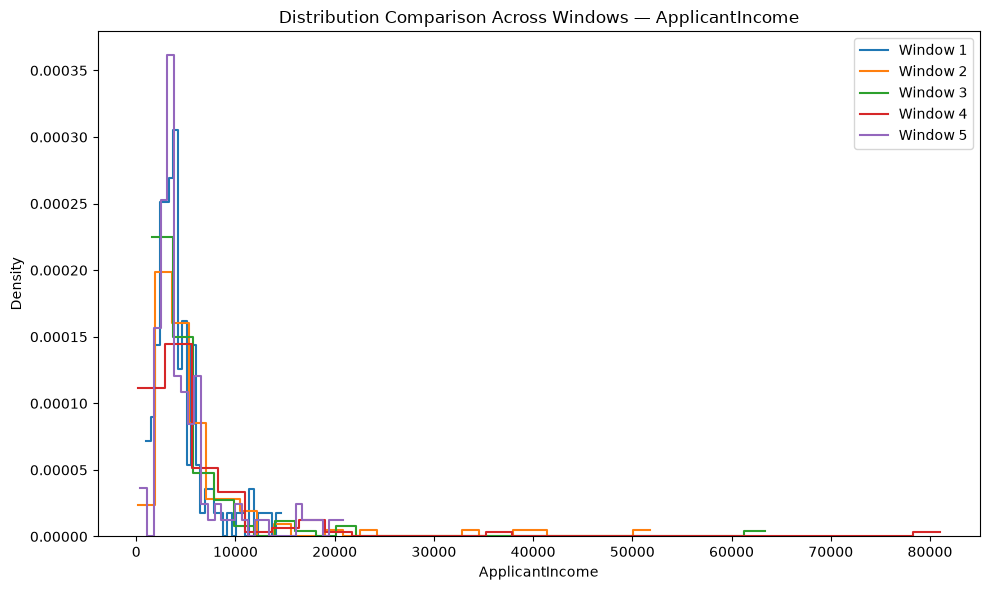

In [19]:
plot_feature_distributions(
    windows,
    "ApplicantIncome"
)

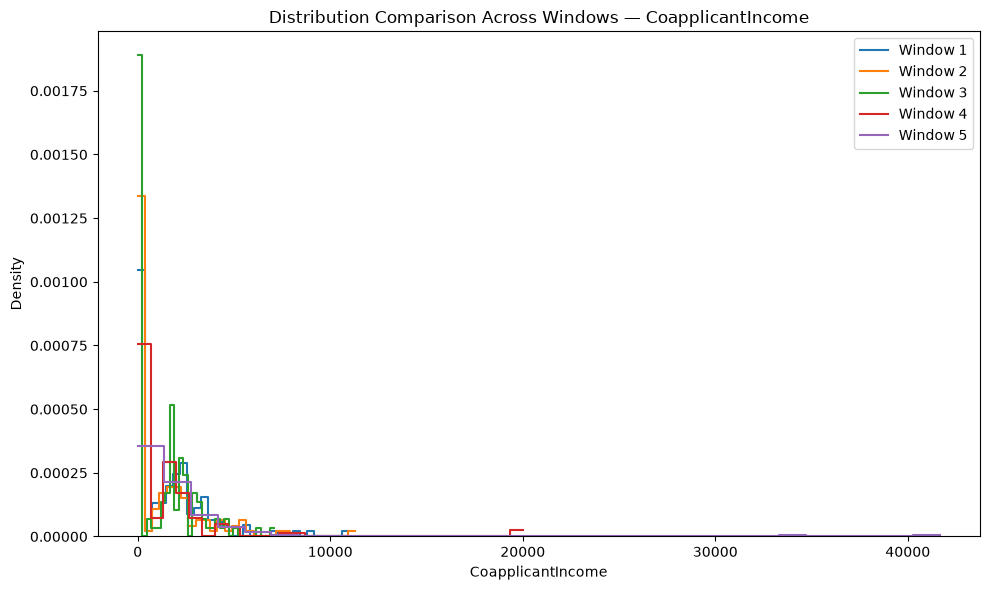

In [20]:
plot_feature_distributions(
    windows,
    "CoapplicantIncome"
)

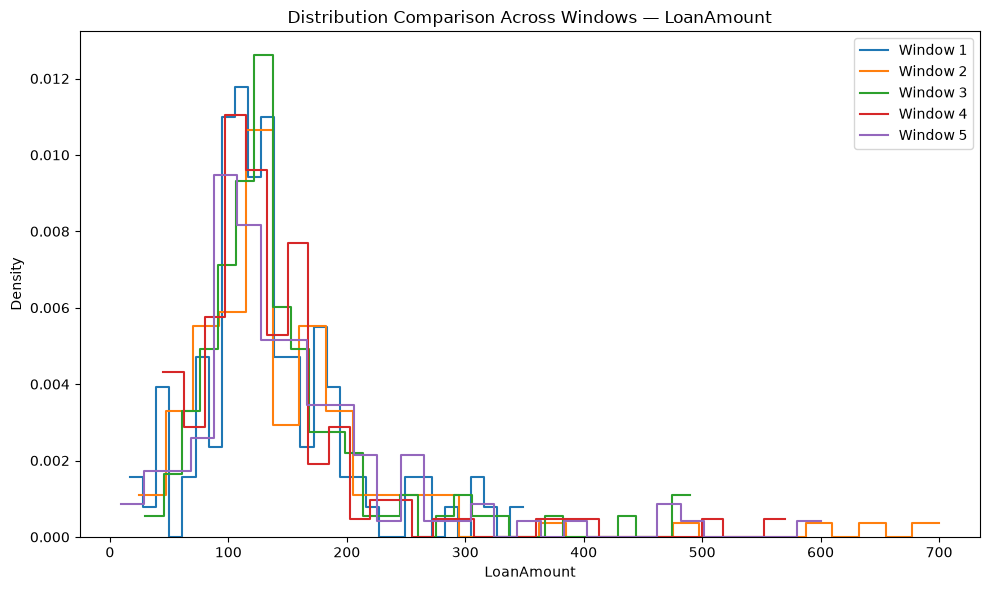

In [21]:
plot_feature_distributions(
    windows,
    "LoanAmount"
)

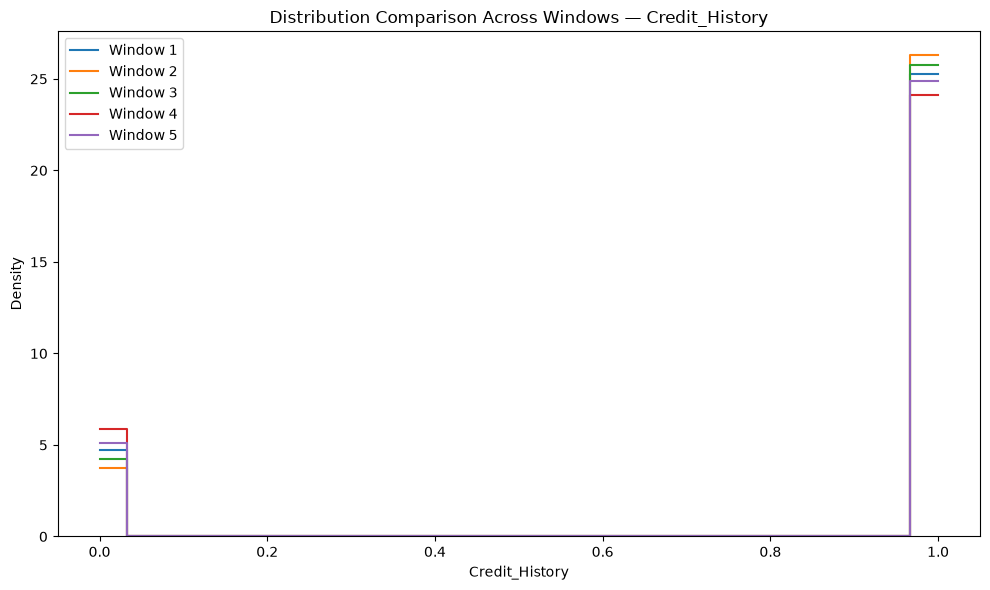

In [22]:
plot_feature_distributions(
    windows,
    "Credit_History"
)

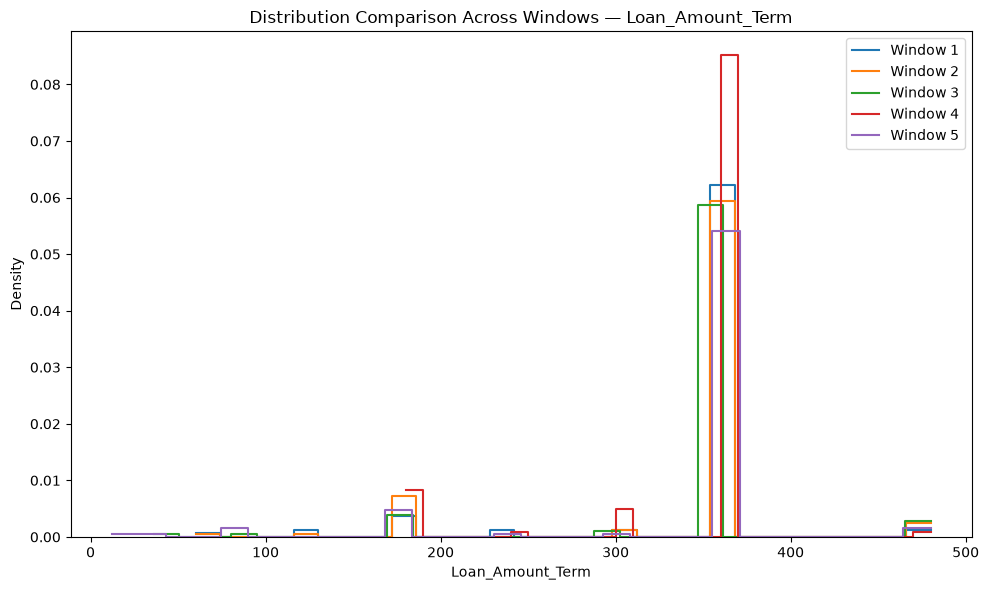

In [23]:
plot_feature_distributions(
    windows,
    "Loan_Amount_Term"
)

### STEP 8.2 — ECDF Comparison

In [24]:
# ============================================================
# ECDF COMPARISON
# ============================================================

def plot_ecdf_comparison(
    windows,
    feature
):

    plt.figure(figsize=(10, 6))

    for i, window in enumerate(windows, start=1):

        values = (
            window[feature]
            .dropna()
            .sort_values()
            .values
        )

        y = np.arange(
            1,
            len(values) + 1
        ) / len(values)

        plt.step(
            values,
            y,
            where="post",
            label=f"Window {i}"
        )

    plt.title(
        f"ECDF Comparison Across Windows — {feature}"
    )

    plt.xlabel(feature)
    plt.ylabel("Empirical Cumulative Probability")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

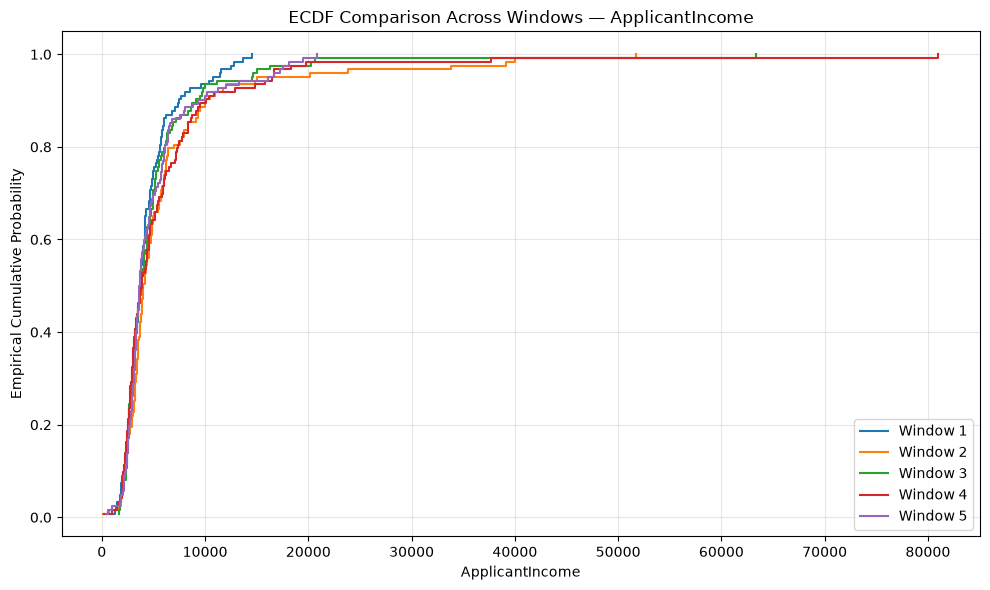

In [25]:
plot_ecdf_comparison(
    windows,
    "ApplicantIncome"
)

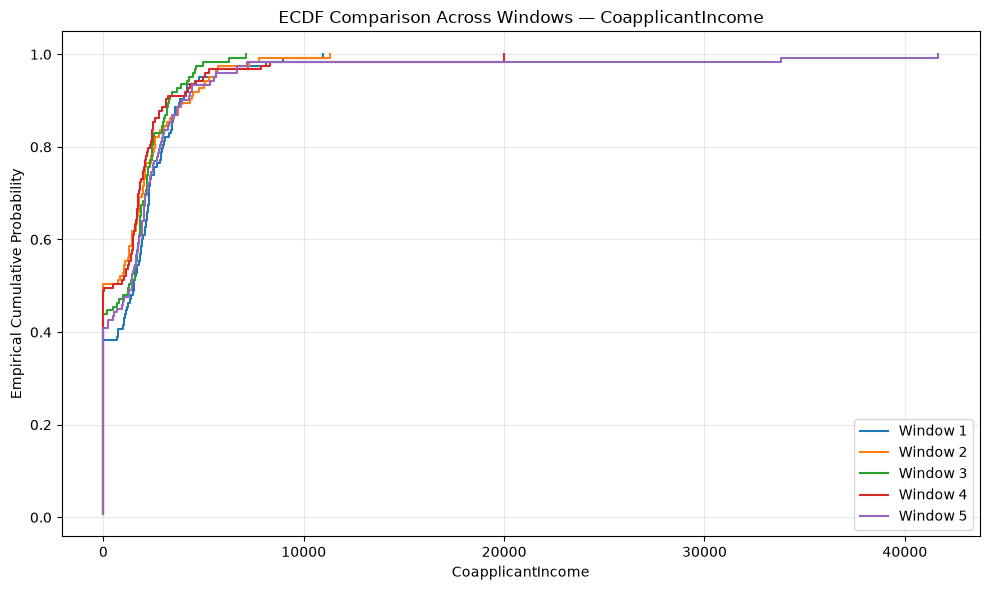

In [26]:
plot_ecdf_comparison(
    windows,
    "CoapplicantIncome"
)

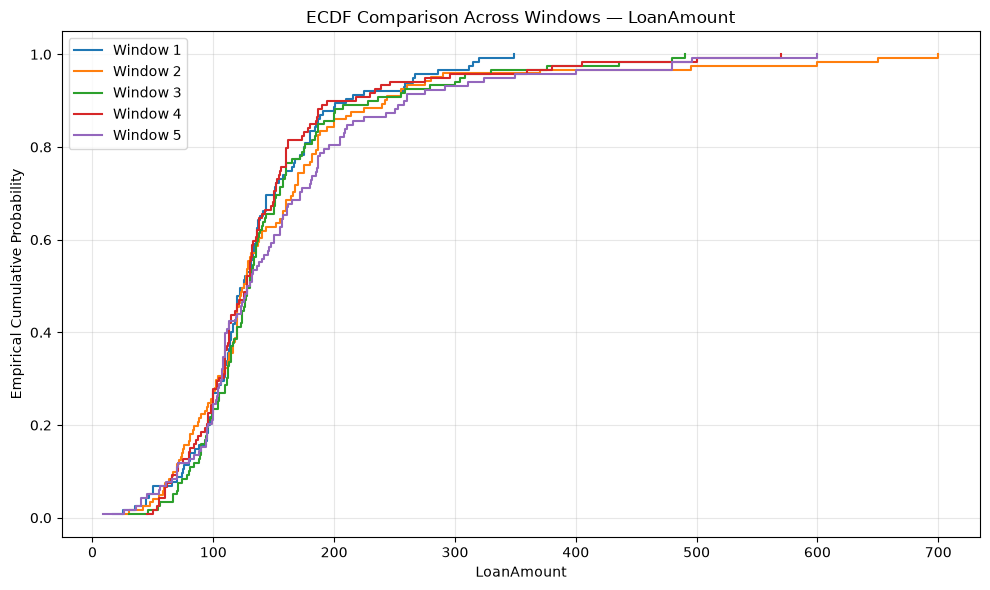

In [27]:
plot_ecdf_comparison(
    windows,
    "LoanAmount"
)

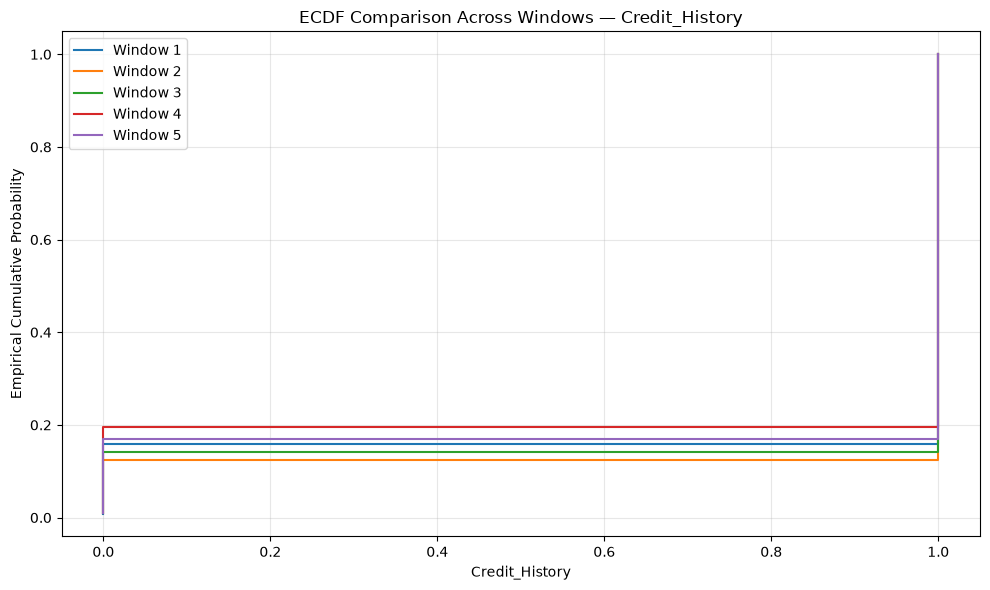

In [28]:
plot_ecdf_comparison(
    windows,
    "Credit_History"
)

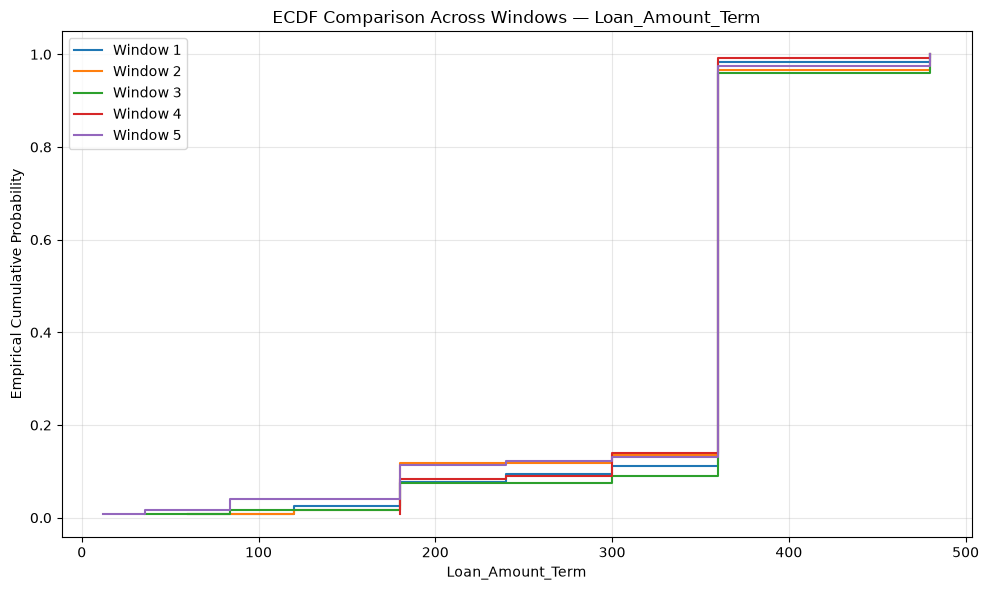

In [29]:
plot_ecdf_comparison(
    windows,
    "Loan_Amount_Term"
)

### STEP 8.3 — Pairwise KS Heatmap

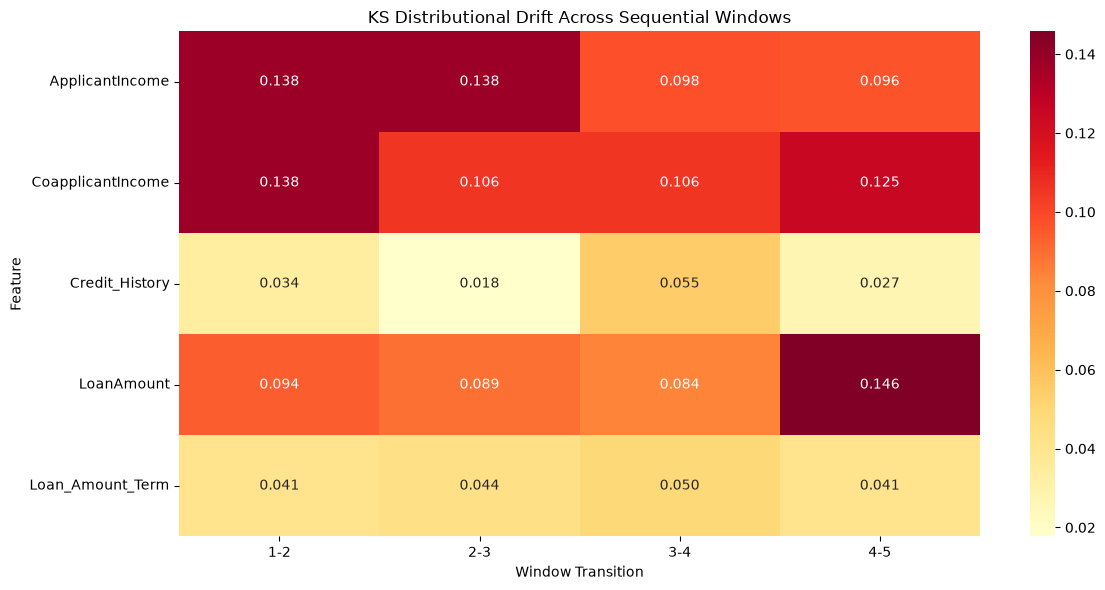

In [30]:
# ============================================================
# KS DRIFT HEATMAP
# ============================================================

ks_heatmap = distribution_drift.pivot(
    index="Feature",
    columns=["Window_From", "Window_To"],
    values="KS_Statistic"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    ks_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd"
)

plt.title(
    "KS Distributional Drift Across Sequential Windows"
)

plt.xlabel("Window Transition")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### STEP 8.4 — PSI Heatmap

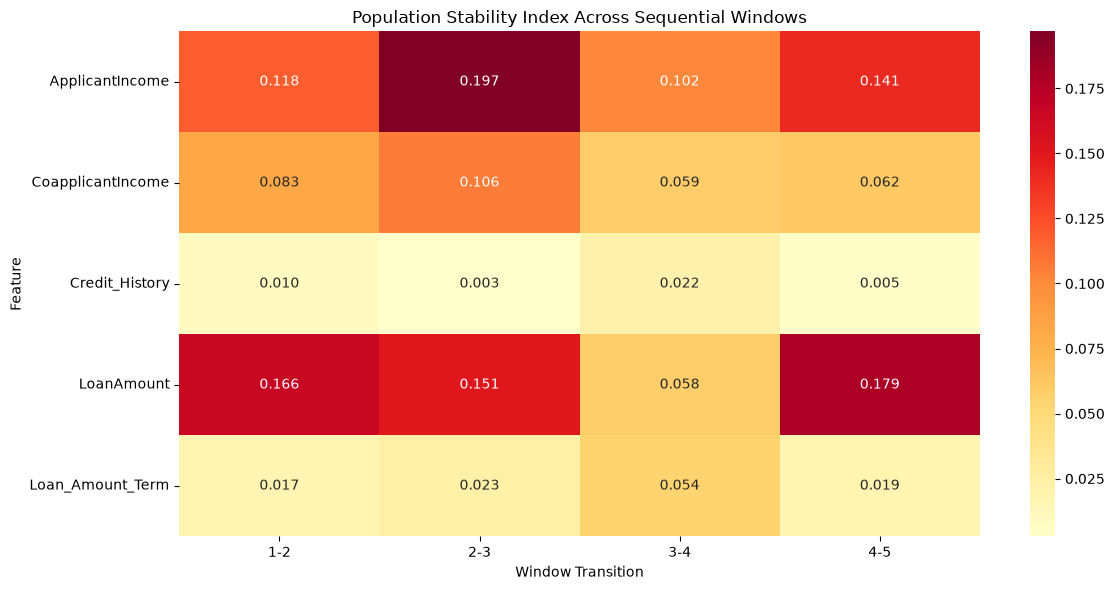

In [31]:
# ============================================================
# PSI DRIFT HEATMAP
# ============================================================

psi_heatmap = distribution_drift.pivot(
    index="Feature",
    columns=["Window_From", "Window_To"],
    values="PSI"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    psi_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd"
)

plt.title(
    "Population Stability Index Across Sequential Windows"
)

plt.xlabel("Window Transition")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### STEP 8.5 — Normalized Wasserstein Heatmap

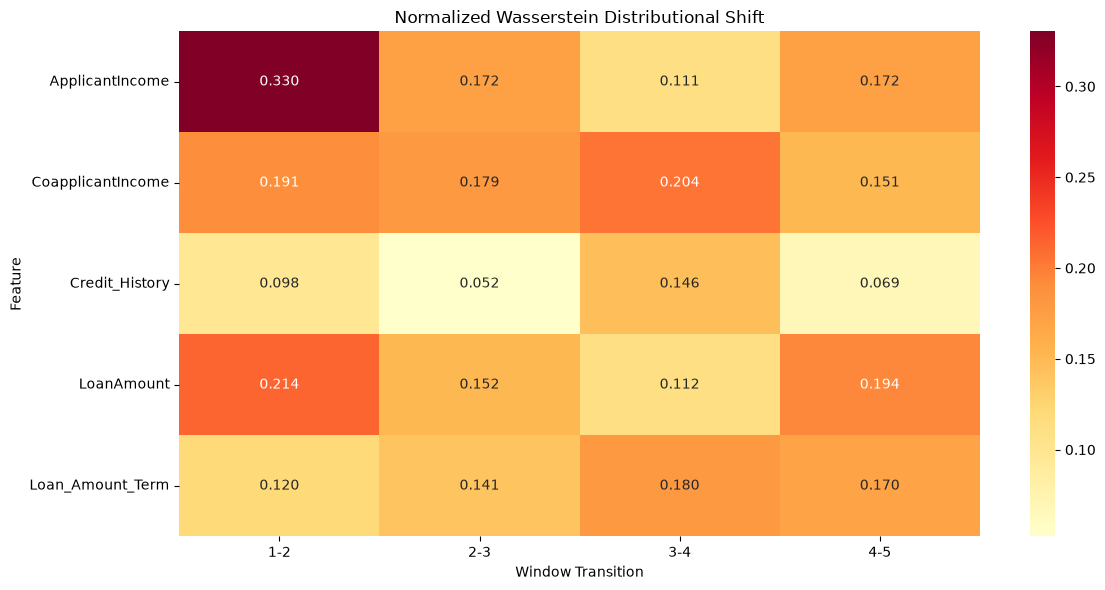

In [32]:
# ============================================================
# NORMALIZED WASSERSTEIN HEATMAP
# ============================================================

wasserstein_heatmap = distribution_drift.pivot(
    index="Feature",
    columns=["Window_From", "Window_To"],
    values="Normalized_Wasserstein"
)

plt.figure(figsize=(12, 6))

sns.heatmap(
    wasserstein_heatmap,
    annot=True,
    fmt=".3f",
    cmap="YlOrRd"
)

plt.title(
    "Normalized Wasserstein Distributional Shift"
)

plt.xlabel("Window Transition")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### STEP 8.6 — Create a Compact Drift Profile

In [33]:
# ============================================================
# DISTRIBUTIONAL DRIFT PROFILE
# ============================================================

drift_profile = distribution_drift_summary.copy()

drift_profile = drift_profile.sort_values(
    "Mean_KS",
    ascending=False
)

drift_profile

,Feature,Mean_KS,Max_KS,Mean_Wasserstein,Max_Wasserstein,Mean_Normalized_Wasserstein,Max_Normalized_Wasserstein,Mean_PSI,Max_PSI
1,CoapplicantIncome,0.118686,0.138211,443.161101,610.908794,0.181500,0.204415,0.077491,0.106472
0,ApplicantIncome,0.117603,0.138211,1240.012961,1848.577236,0.196296,0.330307,0.139479,0.196956
3,LoanAmount,0.103212,0.145777,14.598617,18.448149,0.167815,0.213502,0.138483,0.179010
4,Loan_Amount_Term,0.043710,0.049587,9.680940,11.287088,0.152779,0.180017,0.028301,0.054325
2,Credit_History,0.033330,0.054836,0.033330,0.054836,0.091376,0.146364,0.009673,0.021570


### STEP 8.7 — Identify Consistent vs. Inconsistent Drift Evidence

In [34]:
# ============================================================
# DRIFT RANKINGS
# ============================================================

ks_rank = (
    distribution_drift_summary
    .set_index("Feature")["Mean_KS"]
    .rank(ascending=False)
)

psi_rank = (
    distribution_drift_summary
    .set_index("Feature")["Mean_PSI"]
    .rank(ascending=False)
)

wasserstein_rank = (
    distribution_drift_summary
    .set_index("Feature")[
        "Mean_Normalized_Wasserstein"
    ]
    .rank(ascending=False)
)

drift_rank_comparison = pd.DataFrame({
    "KS_Rank": ks_rank,
    "PSI_Rank": psi_rank,
    "Normalized_Wasserstein_Rank": wasserstein_rank
})

drift_rank_comparison.sort_values(
    "KS_Rank"
)

,KS_Rank,PSI_Rank,Normalized_Wasserstein_Rank
Feature,,,
CoapplicantIncome,1.0,3.0,2.0
ApplicantIncome,2.0,1.0,1.0
LoanAmount,3.0,2.0,3.0
Loan_Amount_Term,4.0,4.0,4.0
Credit_History,5.0,5.0,5.0


### STEP 8.8 — Check Pairwise Drift for ApplicantIncome

In [35]:
applicant_drift = distribution_drift[
    distribution_drift["Feature"] == "ApplicantIncome"
].copy()

applicant_drift

,Feature,Window_From,Window_To,KS_Statistic,KS_pvalue,Wasserstein,Normalized_Wasserstein,PSI
0,ApplicantIncome,1,2,0.138211,0.191061,1848.577236,0.330307,0.118162
1,ApplicantIncome,2,3,0.138211,0.191061,1177.495935,0.171807,0.196956
2,ApplicantIncome,3,4,0.097561,0.603827,818.902439,0.111372,0.101536
3,ApplicantIncome,4,5,0.096428,0.560808,1115.076236,0.171700,0.141261


In [36]:
coapplicant_drift = distribution_drift[
    distribution_drift["Feature"] == "CoapplicantIncome"
].copy()

coapplicant_drift

,Feature,Window_From,Window_To,KS_Statistic,KS_pvalue,Wasserstein,Normalized_Wasserstein,PSI
4,CoapplicantIncome,1,2,0.138211,0.191061,376.894309,0.190849,0.082659
5,CoapplicantIncome,2,3,0.105691,0.499684,316.006504,0.179309,0.106472
6,CoapplicantIncome,3,4,0.105691,0.499684,468.834797,0.204415,0.058893
7,CoapplicantIncome,4,5,0.125150,0.267405,610.908794,0.151426,0.061938


In [37]:
loanamount_drift = distribution_drift[
    distribution_drift["Feature"] == "LoanAmount"
].copy()

loanamount_drift

,Feature,Window_From,Window_To,KS_Statistic,KS_pvalue,Wasserstein,Normalized_Wasserstein,PSI
8,LoanAmount,1,2,0.094071,0.626317,18.448149,0.213502,0.165634
9,LoanAmount,2,3,0.088965,0.677120,13.993819,0.151759,0.150829
10,LoanAmount,3,4,0.084034,0.797056,8.798319,0.111553,0.058459
11,LoanAmount,4,5,0.145777,0.146843,17.154180,0.194445,0.179010


# Distributional Stability — Visual Validation Checkpoint

The quantitative distributional analysis was complemented by visual
validation using:

- Window-wise distribution plots
- Empirical CDF plots
- KS drift heatmap
- PSI drift heatmap
- Normalized Wasserstein heatmap

The visual analysis is used to verify whether the numerical drift measures
correspond to observable changes in feature distributions.

The results are interpreted as complementary evidence rather than as an
independent replacement for the statistical measures.

Features showing consistently higher values across multiple drift metrics
will be treated as candidates for further investigation.

Importantly, distributional instability alone is not considered sufficient
evidence of feature unreliability.

The next stage will investigate whether distributional instability is
associated with changes in model feature importance.

Therefore, the research progression is:

Distributional Stability
        ↓
Feature Importance Consistency
        ↓
Model Performance Impact

This allows the framework to distinguish between:

1. A feature that changes statistically but remains predictive and stable
   in model importance.

2. A feature whose distribution changes and whose model importance also
   changes.

3. A feature whose instability is associated with downstream model
   performance degradation.

This distinction is central to the proposed Data-Centric Feature
Reliability Framework.